# 1) Importar librerias

In [4]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# 2) Importar funciones

In [5]:
def exploracion_inicial(df, tipo=None):
    print("¿Cuántas filas y columnas hay en el conjunto de datos?")
    num_filas, num_columnas = df.shape
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    if tipo == 'simple':
        print("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display(df.head(2))
    else:
        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n=5))

        print("¿Cuáles son las columnas del conjunto de datos?")
        print("\n".join(f"\t- {col}" for col in df.columns))

        print("¿Cuál es el tipo de datos de cada columna?")
        print(df.dtypes)

        print("¿Cuántas columnas hay de cada tipo de datos?")
        print(df.dtypes.value_counts())

        print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
        df.info()

        print("¿Cuántos valores únicos tiene cada columna?")
        print(df.nunique())

        print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
        display(df.describe(include='all').fillna(''))

        print("¿Hay valores nulos en el conjunto de datos?")
        print(df.isnull().sum())

        print("¿Cuál es la proporción de valores nulos en cada columna?")
        print((df.isnull().sum() / len(df) * 100).round(2))

        print("¿Cuántas filas duplicadas hay?")
        print(df.duplicated().sum())

    print('#' * 90)

# 3) Cargar Dataset

In [6]:
df = pd.read_csv(r"C:\Users\andy_\Downloads\Credit_Card_Applications.csv")
df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


# 4) Exploracion inicial y ETL

In [7]:
exploracion_inicial(df)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 690 filas y 16 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


¿Cuáles son las últimas cinco filas del conjunto de datos?


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
685,15808223,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1
686,15769980,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0
687,15675450,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1
688,15776494,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1
689,15592412,1,41.00,0.040,2,10,4,0.040,0,1,1,0,1,560,1,1


¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
517,15748649,0,21.25,2.335,2,3,5,0.50,1,1,4,0,1,80,1,1
98,15664793,0,17.33,9.500,2,6,4,1.75,0,1,10,1,2,0,11,0
333,15711635,1,36.17,0.420,1,9,4,0.29,0,0,0,1,2,309,3,0
84,15636767,1,23.42,1.000,2,8,4,0.50,0,0,0,1,1,280,1,0
210,15788131,0,29.50,0.460,2,4,4,0.54,1,1,4,0,2,380,501,1


¿Cuáles son las columnas del conjunto de datos?
	- CustomerID
	- A1
	- A2
	- A3
	- A4
	- A5
	- A6
	- A7
	- A8
	- A9
	- A10
	- A11
	- A12
	- A13
	- A14
	- Class
¿Cuál es el tipo de datos de cada columna?
CustomerID      int64
A1              int64
A2            float64
A3            float64
A4              int64
A5              int64
A6              int64
A7            float64
A8              int64
A9              int64
A10             int64
A11             int64
A12             int64
A13             int64
A14             int64
Class           int64
dtype: object
¿Cuántas columnas hay de cada tipo de datos?
int64      13
float64     3
Name: count, dtype: int64
¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?
<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1         

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,6.900000e+02,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,1.569047e+07,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,7.150647e+04,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,1.556571e+07,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,1.563169e+07,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.569016e+07,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.575190e+07,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.581544e+07,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


¿Hay valores nulos en el conjunto de datos?
CustomerID    0
A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
A8            0
A9            0
A10           0
A11           0
A12           0
A13           0
A14           0
Class         0
dtype: int64
¿Cuál es la proporción de valores nulos en cada columna?
CustomerID    0.0
A1            0.0
A2            0.0
A3            0.0
A4            0.0
A5            0.0
A6            0.0
A7            0.0
A8            0.0
A9            0.0
A10           0.0
A11           0.0
A12           0.0
A13           0.0
A14           0.0
Class         0.0
dtype: float64
¿Cuántas filas duplicadas hay?
0
##########################################################################################


### 4.1) Procedemos a renombrar las columnas

In [8]:
df.rename(columns={
    'A1':  'genero',
    'A2':  'edad',
    'A3':  'deuda',
    'A4':  'estado_civil',
    'A5':  'num_dependientes',
    'A6':  'nivel_educativo',
    'A7':  'historial_crediticio',
    'A8':  'anios_empleo',
    'A9':  'tiene_propiedad',
    'A10': 'tiene_telefono',
    'A11': 'ingreso_mensual',
    'A12': 'tiene_cuenta_bancaria',
    'A13': 'tipo_cuenta',
    'A14': 'antiguedad_cuenta',
    'A15': 'monto_credito',
    'Class': 'aprobado'
}, inplace=True)

df.head()

,CustomerID,genero,edad,deuda,estado_civil,num_dependientes,nivel_educativo,historial_crediticio,anios_empleo,tiene_propiedad,tiene_telefono,ingreso_mensual,tiene_cuenta_bancaria,tipo_cuenta,antiguedad_cuenta,aprobado
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [21]:
# Genero - OK
df['genero'] = df['genero'].map({0: 'Femenino', 1: 'Masculino'})

# Estado civil - incluimos el 3
df['estado_civil'] = df['estado_civil'].map({
    1: 'Soltero/a',
    2: 'Casado/a',
    3: 'Otro'
})

# Nivel educativo - cubrimos todos los valores presentes
df['nivel_educativo'] = df['nivel_educativo'].map({
    1: 'Sin estudios',
    2: 'Primaria',
    3: 'Secundaria',
    4: 'Bachillerato',
    5: 'Técnico',
    7: 'Posgrado',
    8: 'Otro',
    9: 'Desconocido'
})

# Tiene propiedad - OK
df['tiene_propiedad'] = df['tiene_propiedad'].map({0: 'No', 1: 'Sí'})

# tiene_cuenta_bancaria -> renombrar y mapear como tipo
df.rename(columns={'tiene_cuenta_bancaria': 'tipo_cuenta_bancaria'}, inplace=True)
df['tipo_cuenta_bancaria'] = df['tipo_cuenta_bancaria'].map({
    1: 'Sin cuenta',
    2: 'Ahorro',
    3: 'Corriente'
})

# tiene_telefono y tipo_cuenta -> renombrar como numéricos, NO mapear
df.rename(columns={
    'tiene_telefono': 'consultas_buro',
    'tipo_cuenta':    'saldo_cuenta'
}, inplace=True)

df.head()

,CustomerID,genero,edad,deuda,estado_civil,num_dependientes,nivel_educativo,historial_crediticio,anios_empleo,tiene_propiedad,consultas_buro,ingreso_mensual,tipo_cuenta_bancaria,saldo_cuenta,antiguedad_cuenta,aprobado
0,15776156,Masculino,22.08,11.46,Casado/a,4,Bachillerato,1.585,0,No,0,1,Ahorro,100,1213,0
1,15739548,Femenino,22.67,7.00,Casado/a,8,Bachillerato,0.165,0,No,0,0,Ahorro,160,1,0
2,15662854,Femenino,29.58,1.75,Soltero/a,4,Bachillerato,1.250,0,No,0,1,Ahorro,280,1,0
3,15687688,Femenino,21.67,11.50,Soltero/a,5,Secundaria,0.000,1,Sí,11,1,Ahorro,0,1,1
4,15715750,Masculino,20.17,8.17,Casado/a,6,Bachillerato,1.960,1,Sí,14,0,Ahorro,60,159,1


### 4.2) Vamos a modificar los datos de la columna Edad para redondear y tambien la columna antiguedad cuenta que viene en dias y lo pasaremos a años

In [23]:
# Edad: truncar hacia abajo con floor y convertir a entero
df['edad'] = np.floor(df['edad']).astype(int)

# Verificación
print(df[['edad']].describe())
print("\nEjemplos:")
print(df[['edad']].head())

             edad
count  690.000000
mean    31.118841
std     11.852887
min     13.000000
25%     22.000000
50%     28.000000
75%     37.000000
max     80.000000

Ejemplos:
   edad
0    22
1    22
2    29
3    21
4    20


- Edad mínima 13 años → puede ser un outlier o error de datos, vale la pena revisarlo
- Edad máxima 80 años → también llamativo para un solicitante de crédito
- Media 31 años con mediana 28 → distribución algo sesgada hacia la derecha

In [24]:
# Ver registros con edades extremas
print("=== Menores de 18 ===")
print(df[df['edad'] < 18][['edad', 'deuda', 'anios_empleo', 'aprobado']])

print("\n=== Mayores de 70 ===")
print(df[df['edad'] > 70][['edad', 'deuda', 'anios_empleo', 'aprobado']])

=== Menores de 18 ===
     edad   deuda  anios_empleo  aprobado
5      15   0.585             1         1
6      17   6.500             0         0
47     16   0.040             0         1
98     17   9.500             0         0
144    16   1.250             0         0
147    15   2.875             0         0
152    15   7.000             0         0
168    17   0.205             0         0
190    17   3.000             0         0
197    17   0.250             0         0
198    16   0.335             0         0
245    16   0.500             0         0
246    16   0.165             0         0
260    16   2.750             0         0
272    16   0.125             0         0
277    16   0.835             1         0
304    15   7.625             0         0
318    15   0.375             0         0
357    16   3.125             0         0
381    17   3.290             0         0
383    16   0.000             0         0
435    16   0.750             1         1
449    16   

### 4.3) Hay 35 filas con datos incorrectos ya que hay menores de 18 años y no pueden solicitar un crédito, es un 5% de dataset y es un impacto minimo en el análisis

In [25]:
# Registros antes
print(f"Filas antes: {len(df)}")

# Eliminar menores de 18
df = df[df['edad'] >= 18].reset_index(drop=True)

# Verificación
print(f"Filas después: {len(df)}")
print(f"Filas eliminadas: {690 - len(df)}")
print(f"\nEdad mínima ahora: {df['edad'].min()}")
print(f"Edad máxima ahora: {df['edad'].max()}")

Filas antes: 690
Filas después: 655
Filas eliminadas: 35

Edad mínima ahora: 18
Edad máxima ahora: 80


### 4.4) Modificamos anios_empleo e ingreso_mensual que son categóricas

In [ ]:
# anios_empleo → binaria
df['anios_empleo'] = df['anios_empleo'].map({0: 'No empleado', 1: 'Empleado'})

# ingreso_mensual → binaria
df['ingreso_mensual'] = df['ingreso_mensual'].map({0: 'Sin ingreso', 1: 'Con ingreso'})

# Verificación
print(df['anios_empleo'].value_counts())
print()
print(df['ingreso_mensual'].value_counts())

### 4.5) Guardar dataset limpio en CSV


In [35]:
# Guardar dataset limpio en CSV
df.to_csv('credit_data_clean.csv', index=False)

# Verificación
print("✅ Dataset guardado como 'credit_data_clean.csv'")
print(f"   Filas: {df.shape[0]}")
print(f"   Columnas: {df.shape[1]}")
print(f"   Columnas: {list(df.columns)}")

✅ Dataset guardado como 'credit_data_clean.csv'
   Filas: 655
   Columnas: 16
   Columnas: ['CustomerID', 'genero', 'edad', 'deuda', 'estado_civil', 'num_dependientes', 'nivel_educativo', 'historial_crediticio', 'anios_empleo', 'tiene_propiedad', 'consultas_buro', 'ingreso_mensual', 'tipo_cuenta_bancaria', 'saldo_cuenta', 'antiguedad_cuenta', 'aprobado']


# 5) EDA

### 5.1 Distribución de variables númericas

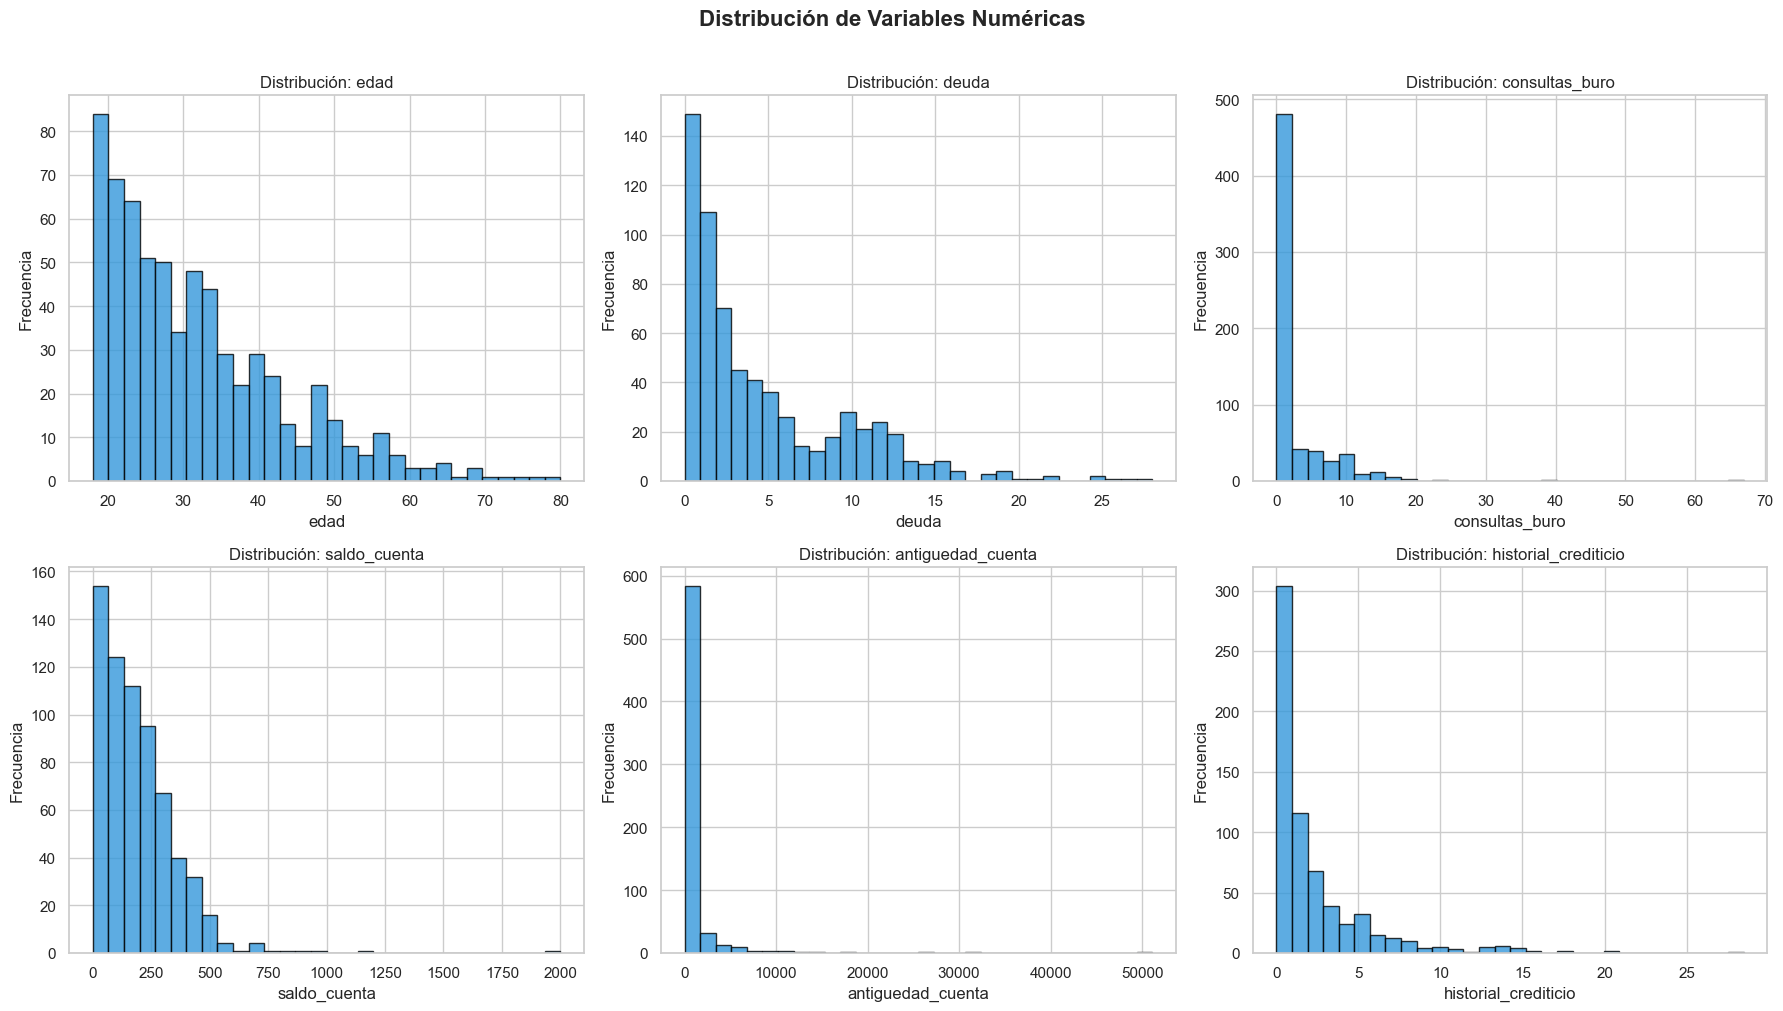

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

numericas = ['edad', 'deuda', 'consultas_buro', 'saldo_cuenta', 'antiguedad_cuenta',
             'historial_crediticio']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribución: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Distribución de variables categóricas

C:\Users\andy_\AppData\Local\Temp\ipykernel_11988\1786092206.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=orden,
C:\Users\andy_\AppData\Local\Temp\ipykernel_11988\1786092206.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=orden,
C:\Users\andy_\AppData\Local\Temp\ipykernel_11988\1786092206.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=orden,
C:\Users\andy_\AppData\Local\Temp\ipykernel_11988\1786092206.py:9: FutureWarnin

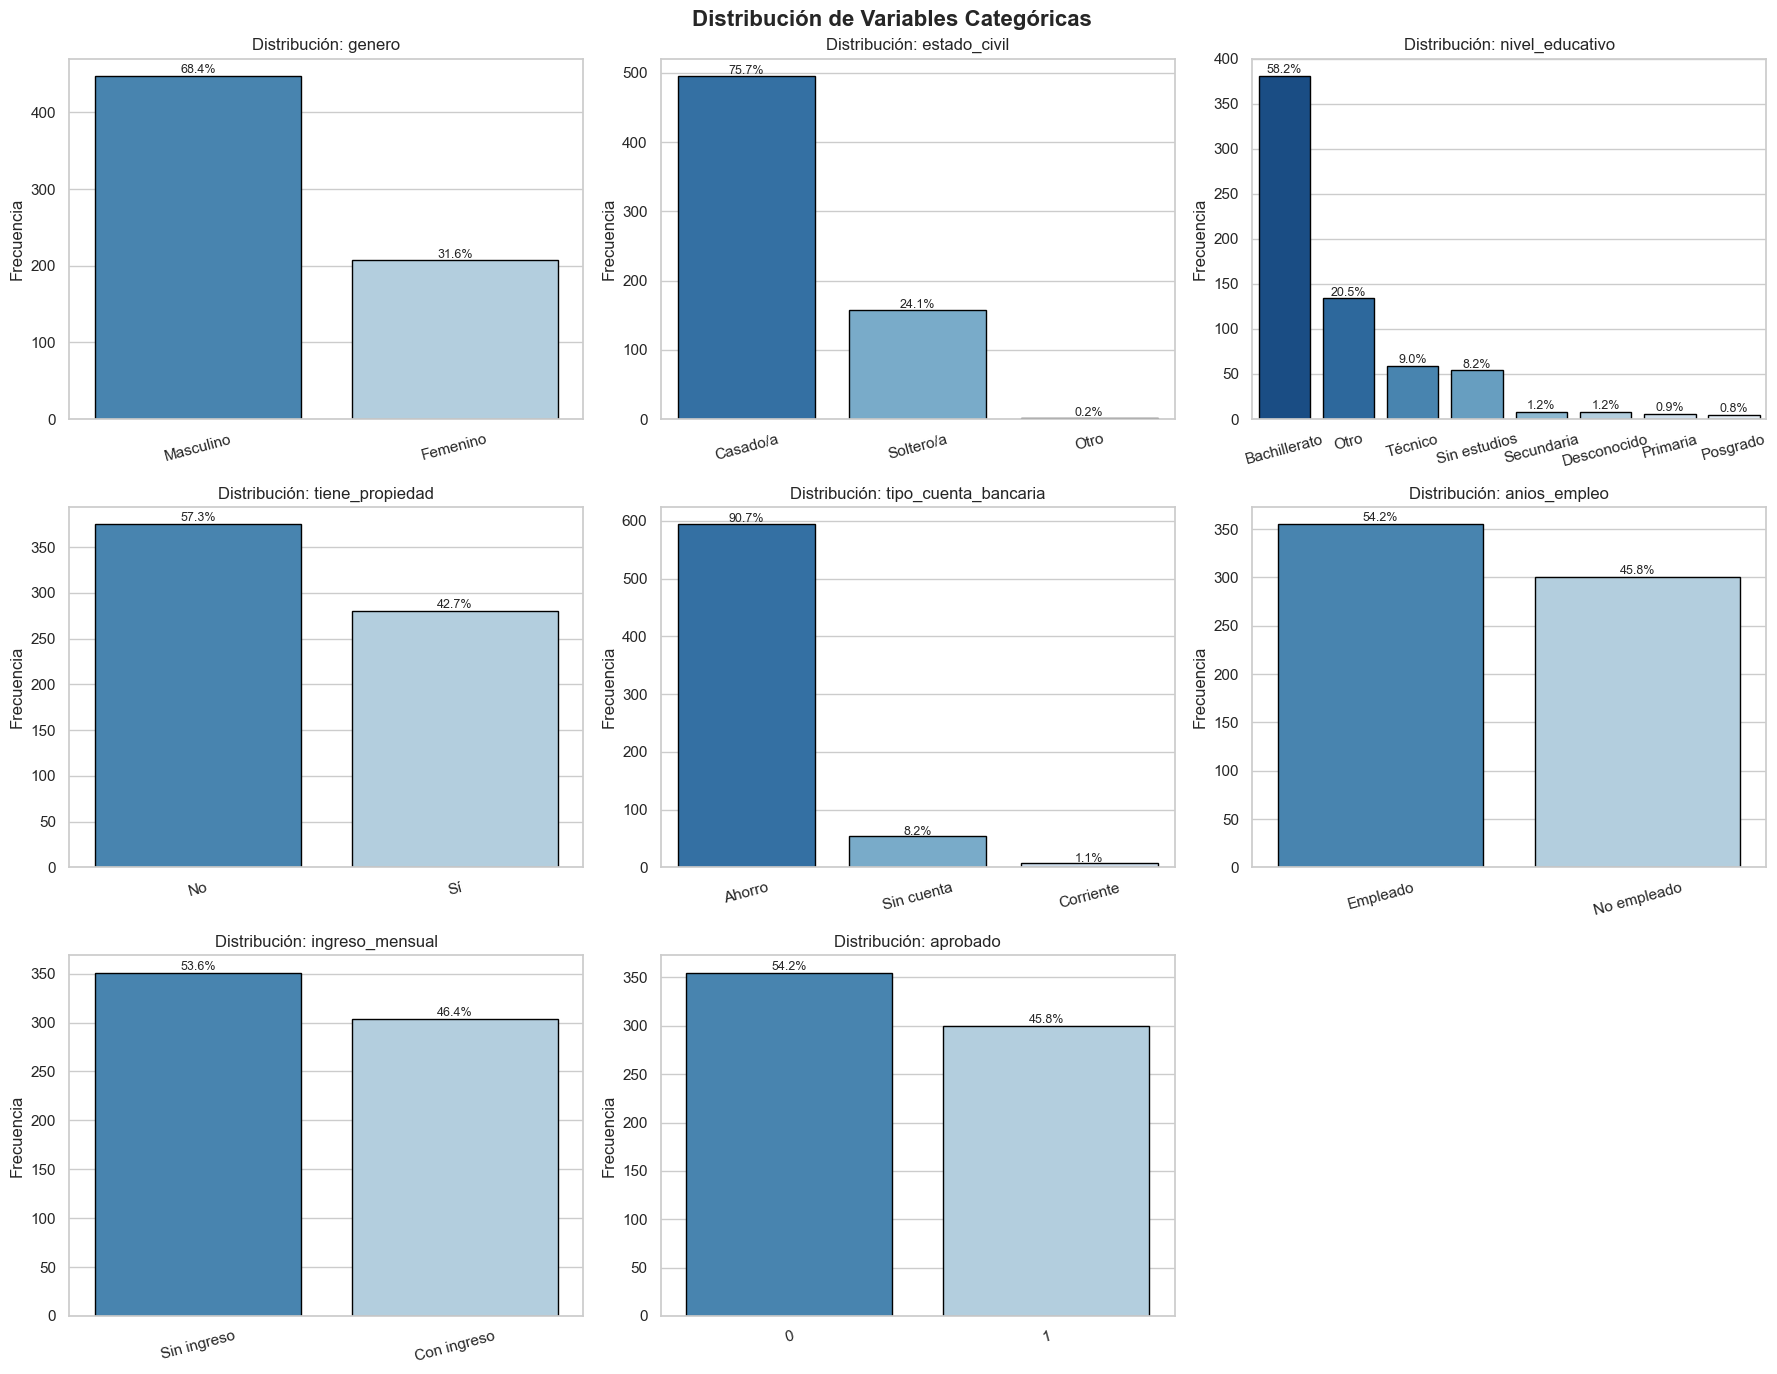

In [32]:
categoricas = ['genero', 'estado_civil', 'nivel_educativo', 'tiene_propiedad', 
               'tipo_cuenta_bancaria', 'anios_empleo', 'ingreso_mensual', 'aprobado']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    orden = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=orden,
                  palette='Blues_r', edgecolor='black')
    axes[i].set_title(f'Distribución: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=15)

    total = len(df)
    for p in axes[i].patches:
        pct = f'{100 * p.get_height() / total:.1f}%'
        axes[i].annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 3),
                        ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3) Aprobado vs rechazado

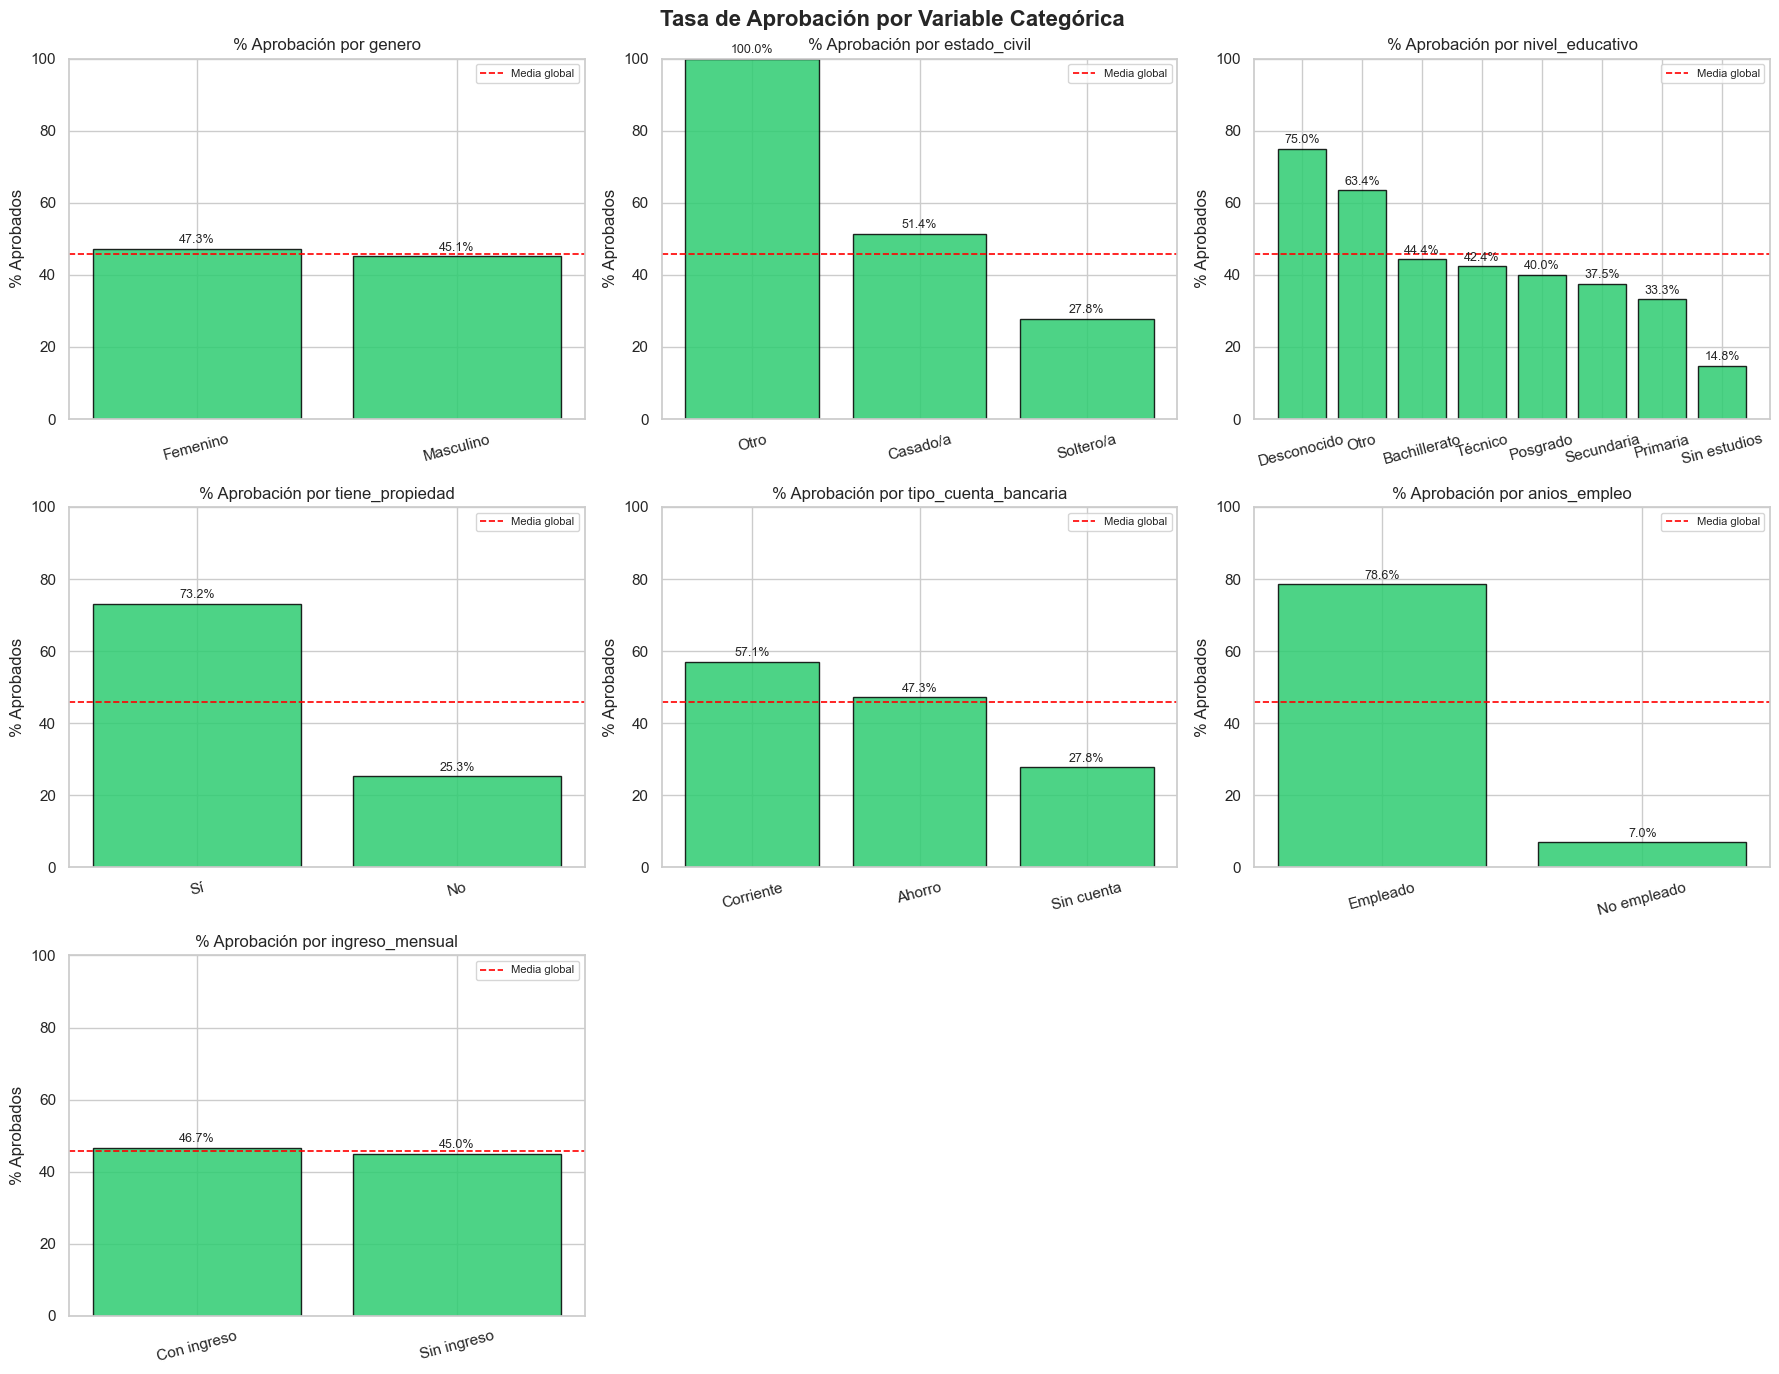

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

categoricas = ['genero', 'estado_civil', 'nivel_educativo', 'tiene_propiedad',
               'tipo_cuenta_bancaria', 'anios_empleo', 'ingreso_mensual']

for i, col in enumerate(categoricas):
    tasa = df.groupby(col)['aprobado'].mean().mul(100).round(1).sort_values(ascending=False)
    bars = axes[i].bar(tasa.index, tasa.values, color='#2ecc71', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'% Aprobación por {col}', fontsize=12)
    axes[i].set_ylabel('% Aprobados')
    axes[i].set_ylim(0, 100)
    axes[i].axhline(y=df['aprobado'].mean()*100, color='red', linestyle='--', linewidth=1.2, label='Media global')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, tasa.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 1.5, f'{val}%', ha='center', fontsize=9)

axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.suptitle('Tasa de Aprobación por Variable Categórica', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\andy_\AppData\Local\Temp\ipykernel_11988\372570581.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['aprobado'].map({0: 'Rechazado', 1: 'Aprobado'}),
C:\Users\andy_\AppData\Local\Temp\ipykernel_11988\372570581.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['aprobado'].map({0: 'Rechazado', 1: 'Aprobado'}),
C:\Users\andy_\AppData\Local\Temp\ipykernel_11988\372570581.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['aprobado'].map({0: 'Rechazado', 1: 'Aprobado'}),
C:\Users\andy_\AppD

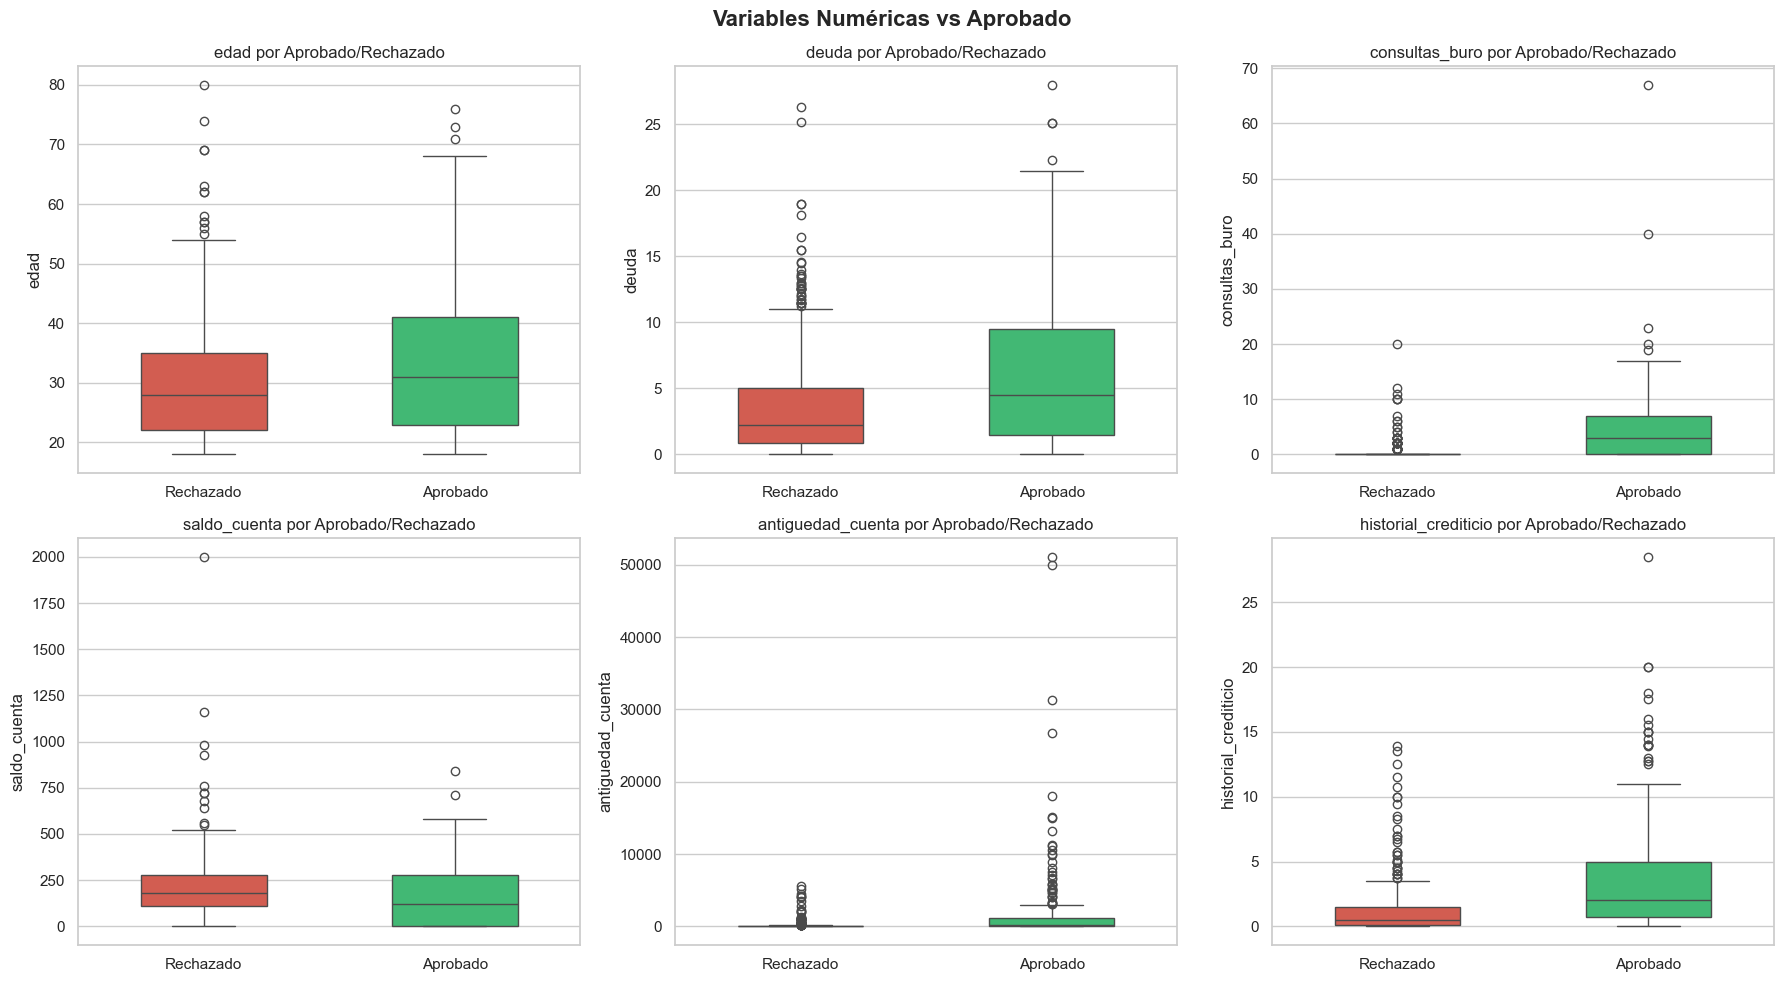

In [38]:
numericas = ['edad', 'deuda', 'consultas_buro', 'saldo_cuenta', 
             'antiguedad_cuenta', 'historial_crediticio']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(data=df, x=df['aprobado'].map({0: 'Rechazado', 1: 'Aprobado'}), 
                y=col, ax=axes[i],
                palette={'Rechazado': '#e74c3c', 'Aprobado': '#2ecc71'}, 
                order=['Rechazado', 'Aprobado'],
                width=0.5)
    axes[i].set_title(f'{col} por Aprobado/Rechazado', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Variables Numéricas vs Aprobado', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

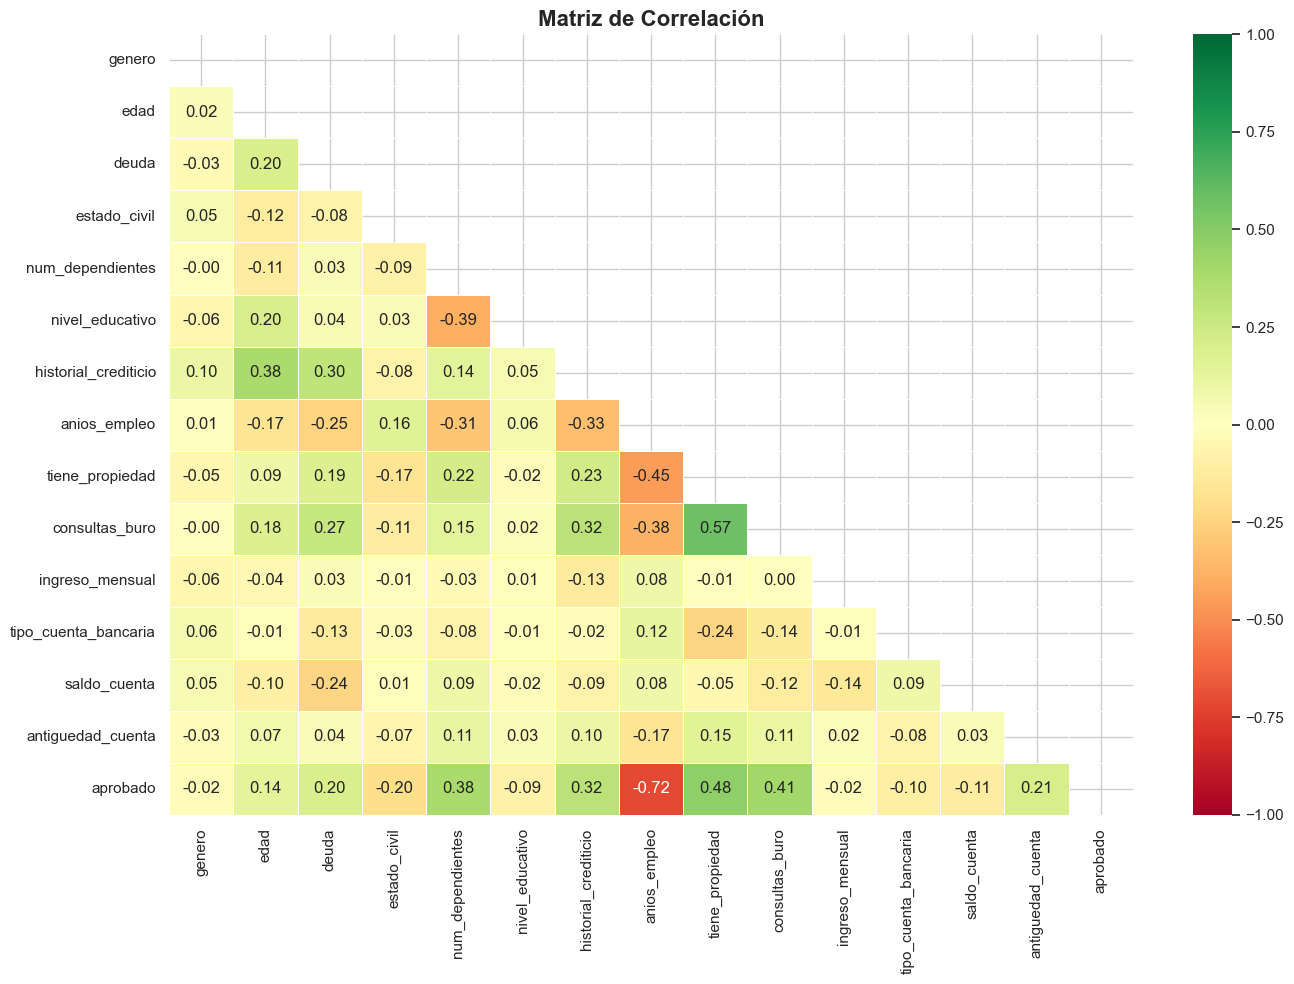

In [39]:
# Codificación temporal para correlación
df_corr = df.copy()
cat_cols = ['genero', 'estado_civil', 'nivel_educativo', 'tiene_propiedad',
            'tipo_cuenta_bancaria', 'anios_empleo', 'ingreso_mensual']

for col in cat_cols:
    df_corr[col] = df_corr[col].astype('category').cat.codes

df_corr = df_corr.drop(columns=['CustomerID'])

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

1. Las correlaciones más relevantes son:
- VariableCorrelaciónInterpretaciónanios_empleo-0.72 🔴La más fuerte — estar no empleado se asocia fuertemente al rechazotiene_propiedad+0.48 🟢Tener propiedad aumenta significativamente la aprobaciónconsultas_buro+0.41 🟢Más consultas → más aprobados, posiblemente perfiles más activos financieramentenum_dependientes+0.38 🟡Sorprendente positivo, más dependientes no penalizahistorial_crediticio+0.32 🟡Más historial → más aprobación, confirma tu intuicióndeuda+0.20 🟡Leve positivo — más deuda en aprobados, puede ser efecto causal inversoedad+0.14 ⚪Leve positivo, más edad más aprobaciónestado_civil-0.20 🟡Solteros tienen menor tasa de aprobacióningreso_mensual-0.02 ⚪Prácticamente sin correlación lineal — sorprendentegenero-0.02 ⚪Sin correlación, confirma la simetría que observaste

2. Correlaciones entre variables independientes destacables:

- anios_empleo ↔ tiene_propiedad -0.45 → Los no empleados tienden a no tener propiedad
- anios_empleo ↔ consultas_buro -0.38 → Los no empleados consultan menos el buró
- consultas_buro ↔ tiene_propiedad +0.57 → La más alta entre independientes, los que tienen propiedad consultan más el buró, probablemente son perfiles financieramente más activos
- num_dependientes ↔ nivel_educativo -0.39 → A menor nivel educativo, más dependientes

# 6) Machine Learning / Predicciones

### 6.1) Regresión logística

#### 6.1.1) Preparación de datos:

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Variables categóricas a codificar
cat_cols = ['genero', 'estado_civil', 'nivel_educativo', 'tiene_propiedad',
            'tipo_cuenta_bancaria', 'anios_empleo', 'ingreso_mensual']

# One-Hot Encoding
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Eliminar CustomerID
df_model = df_model.drop(columns=['CustomerID'])

# Separar X e y
X = df_model.drop(columns=['aprobado'])
y = df_model['aprobado']

print(f"Shape X: {X.shape}")
print(f"Columnas: {list(X.columns)}")

Shape X: (655, 22)
Columnas: ['edad', 'deuda', 'num_dependientes', 'historial_crediticio', 'consultas_buro', 'saldo_cuenta', 'antiguedad_cuenta', 'genero_Masculino', 'estado_civil_Otro', 'estado_civil_Soltero/a', 'nivel_educativo_Desconocido', 'nivel_educativo_Otro', 'nivel_educativo_Posgrado', 'nivel_educativo_Primaria', 'nivel_educativo_Secundaria', 'nivel_educativo_Sin estudios', 'nivel_educativo_Técnico', 'tiene_propiedad_Sí', 'tipo_cuenta_bancaria_Corriente', 'tipo_cuenta_bancaria_Sin cuenta', 'anios_empleo_No empleado', 'ingreso_mensual_Sin ingreso']


#### 6.1.2) Split y escalado:

In [41]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado solo de columnas numéricas
numericas = ['edad', 'deuda', 'consultas_buro', 'saldo_cuenta', 
             'antiguedad_cuenta', 'historial_crediticio', 'num_dependientes']

scaler = StandardScaler()
X_train[numericas] = scaler.fit_transform(X_train[numericas])
X_test[numericas]  = scaler.transform(X_test[numericas])

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (524, 22) | Test: (131, 22)


#### 6.1.3) Entrenamiento y evaliación:

In [42]:
# Entrenar modelo
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Predicciones
y_pred  = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]

# Métricas
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Rechazado', 'Aprobado']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Rechazado       0.91      0.89      0.90        71
    Aprobado       0.87      0.90      0.89        60

    accuracy                           0.89       131
   macro avg       0.89      0.89      0.89       131
weighted avg       0.89      0.89      0.89       131

ROC-AUC: 0.9688


Un AUC por encima de 0.95 es considerado excelente — significa que el modelo tiene una capacidad de discriminación casi perfecta entre aprobados y rechazados. La curva ROC prácticamente pegada a la esquina superior izquierda lo confirma visualmente

#### 6.1.4) Visualizaciones:

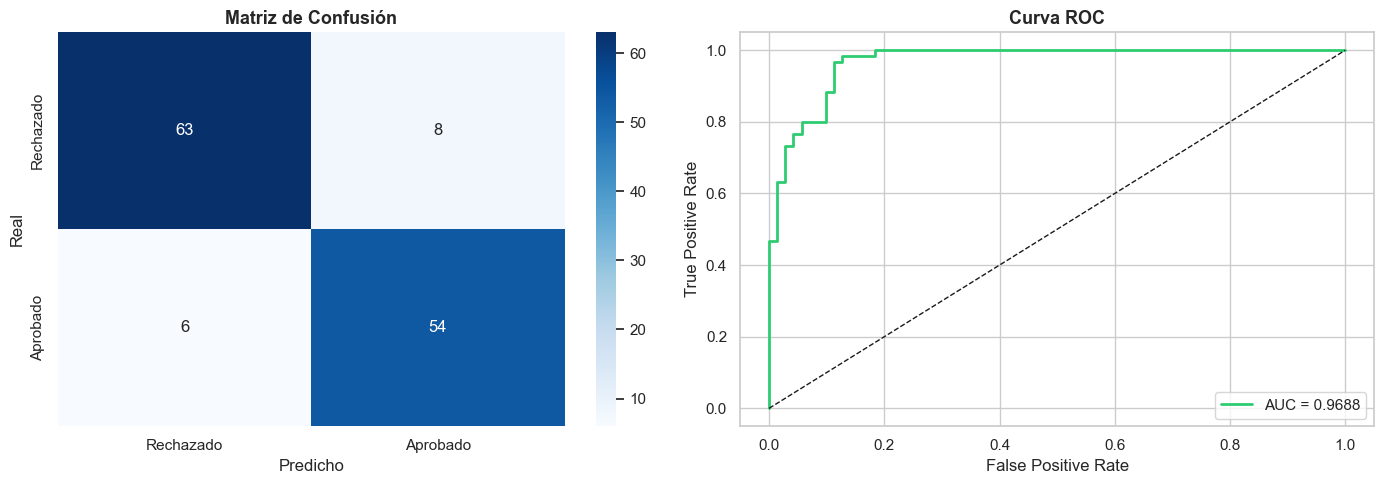

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'])
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2ecc71', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

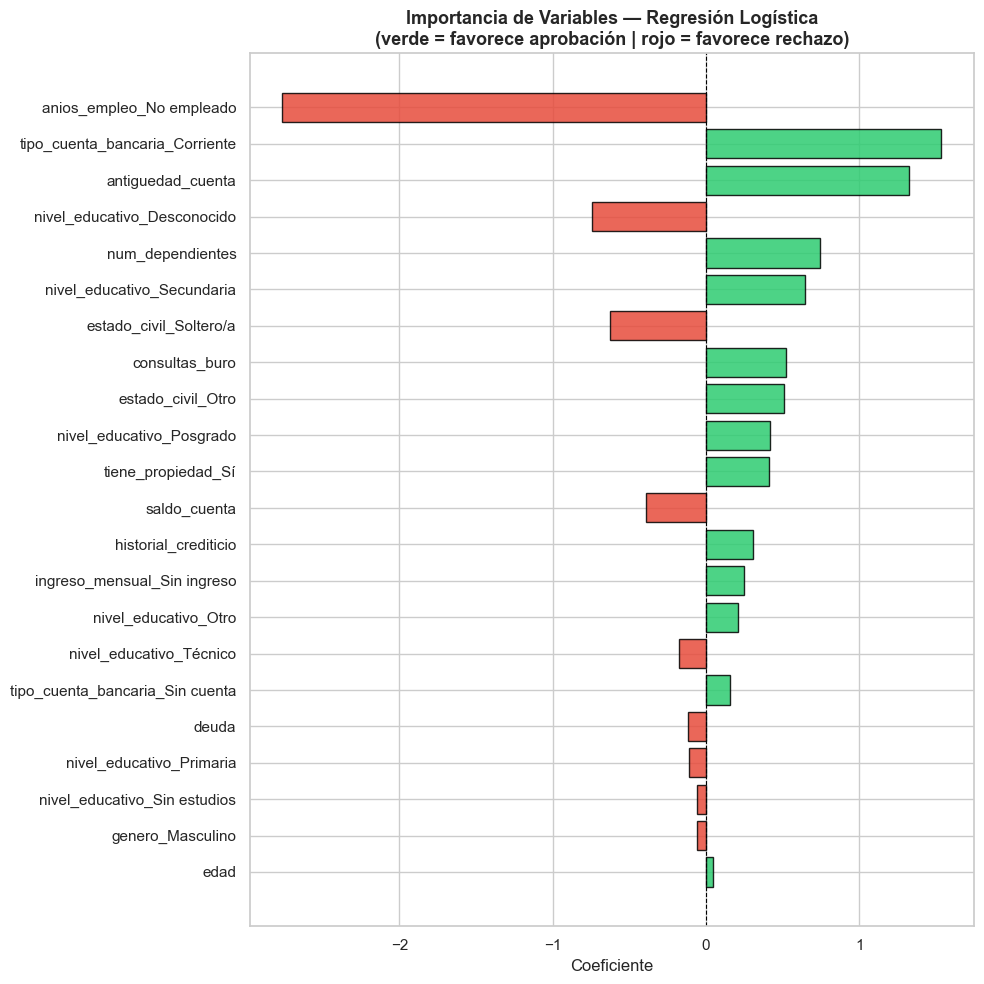

In [44]:
# Importancia de coeficientes en Regresión Logística
coeficientes = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': model_lr.coef_[0]
})

# Ordenar por valor absoluto
coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()
coeficientes = coeficientes.sort_values('abs_coef', ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coeficientes['coeficiente']]
ax.barh(coeficientes['variable'], coeficientes['coeficiente'], color=colors, edgecolor='black', alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Importancia de Variables — Regresión Logística\n(verde = favorece aprobación | rojo = favorece rechazo)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

1. Variables que más favorecen el RECHAZO 🔴
- VariableInterpretaciónanios_empleo_No empleadoCon diferencia la más importante — no tener empleo es el mayor predictor de rechazonivel_educativo_DesconocidoDatos incompletos en la ficha generan desconfianzaestado_civil_Soltero/aLos solteros tienen menor probabilidad de aprobaciónsaldo_cuentaCurioso — más saldo penaliza, puede ser un efecto espurio del dataset

2. Variables que más favorecen la APROBACIÓN 🟢
- VariableInterpretacióntipo_cuenta_bancaria_CorrienteTener cuenta corriente es el mayor predictor positivoantiguedad_cuentaA mayor antigüedad de cuenta, más confianza generanum_dependientesSorprendente pero consistente con lo que vimos en correlaciónnivel_educativo_SecundariaInteresante, supera a niveles educativos más altosconsultas_buroMás consultas = perfil más activo financieramentetiene_propiedad_SíConfirma lo esperado, la propiedad como aval

### 6.2) Random Forest

#### 6.2.1) Entrenamiento

In [45]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf  = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# Métricas
print("=== CLASSIFICATION REPORT — RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Rechazado', 'Aprobado']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== CLASSIFICATION REPORT — RANDOM FOREST ===
              precision    recall  f1-score   support

   Rechazado       0.93      0.90      0.91        71
    Aprobado       0.89      0.92      0.90        60

    accuracy                           0.91       131
   macro avg       0.91      0.91      0.91       131
weighted avg       0.91      0.91      0.91       131

ROC-AUC: 0.9663


#### 6.2.2) Visualizaciones

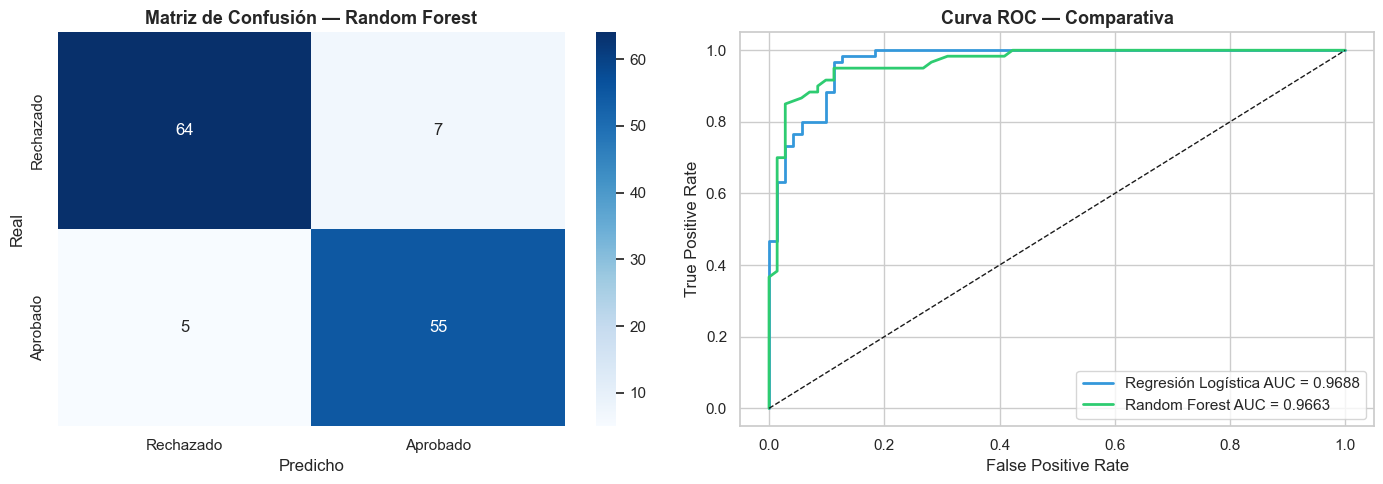

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'])
axes[0].set_title('Matriz de Confusión — Random Forest', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC comparativa LR vs RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'Regresión Logística AUC = {auc:.4f}')
axes[1].plot(fpr_rf, tpr_rf, color='#2ecc71', linewidth=2, label=f'Random Forest AUC = {auc_rf:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('Curva ROC — Comparativa', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

- Matriz de confusión comparada:
- Reg. LogísticaRandom Forest✅ Rechazos correctos6364✅ Aprobaciones correctas5455⚠️ Falsos positivos (aprobó sin deber)87⚠️ Falsos negativos (rechazó sin deber)65
- Random Forest mejora en todos los indicadores — 1 error menos en cada tipo.
- Sobre la curva ROC comparativa:
Visualmente casi idénticas, con la Regresión Logística ligeramente por encima en la zona crítica (FPR 0.0-0.2), que es precisamente donde más importa en crédito — minimizar falsos positivos a umbrales de alta confianza.

### 6.3 XGBoost

#### 6.3.1) Entrenamiento

In [49]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=100, random_state=42, 
                           eval_metric='logloss', verbosity=0)
model_xgb.fit(X_train, y_train)

# Predicciones
y_pred_xgb  = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Métricas
print("=== CLASSIFICATION REPORT — XGBOOST ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Rechazado', 'Aprobado']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

=== CLASSIFICATION REPORT — XGBOOST ===
              precision    recall  f1-score   support

   Rechazado       0.88      0.86      0.87        71
    Aprobado       0.84      0.87      0.85        60

    accuracy                           0.86       131
   macro avg       0.86      0.86      0.86       131
weighted avg       0.86      0.86      0.86       131

ROC-AUC: 0.9568


#### 6.3.2) Visualizaciones

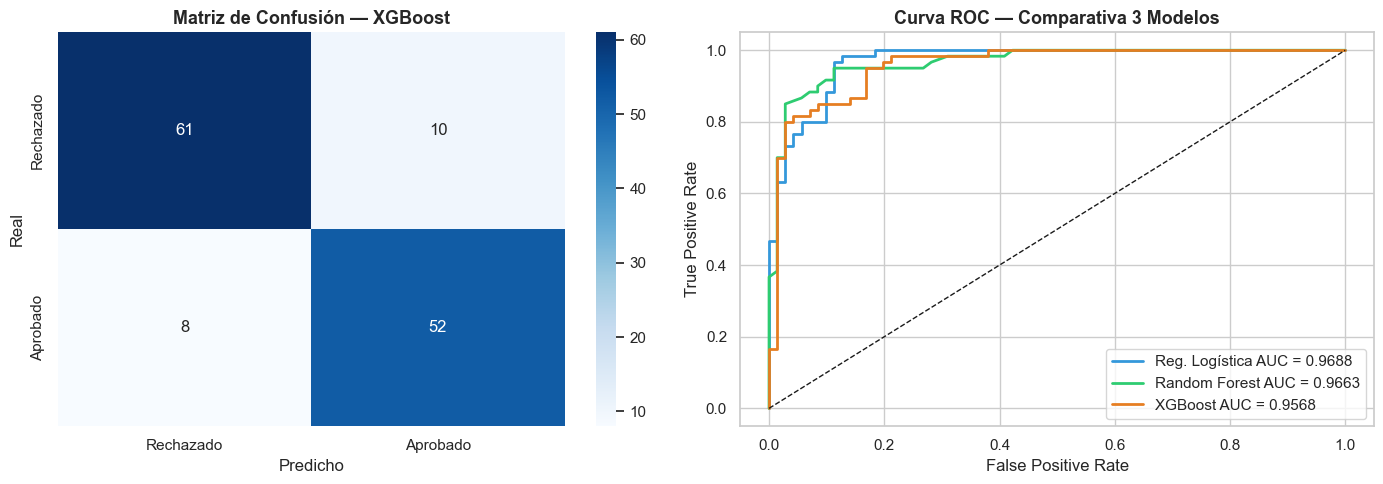

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'])
axes[0].set_title('Matriz de Confusión — XGBoost', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC comparativa de los 3 modelos
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, 
             label=f'Reg. Logística AUC = {auc:.4f}')
axes[1].plot(fpr_rf, tpr_rf, color='#2ecc71', linewidth=2, 
             label=f'Random Forest AUC = {auc_rf:.4f}')
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, color='#e67e22', linewidth=2, 
             label=f'XGBoost AUC = {auc_xgb:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('Curva ROC — Comparativa 3 Modelos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

#### 6.3.3) Importancia variables

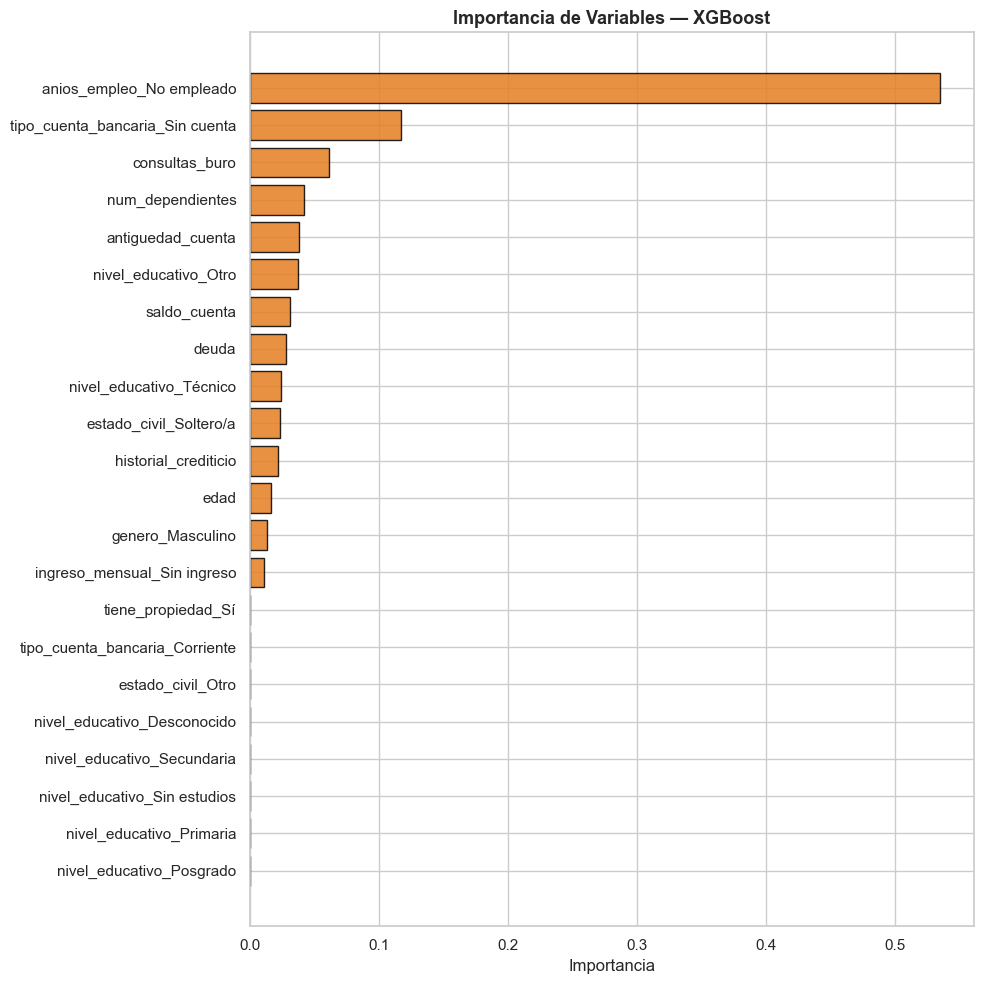

In [51]:
importancias_xgb = pd.DataFrame({
    'variable': X_train.columns,
    'importancia': model_xgb.feature_importances_
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(importancias_xgb['variable'], importancias_xgb['importancia'],
        color='#e67e22', edgecolor='black', alpha=0.85)
ax.set_title('Importancia de Variables — XGBoost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

- Resumen de los 3 modelos:
1. MétricaReg. LogísticaRandom ForestXGBoostAccuracy89%91%86%ROC-AUC0.96880.96630.9568F1 Rechazado0.900.910.87F1 Aprobado0.890.900.85Falsos positivos8710Falsos negativos658
2. ¿Por qué XGBoost ha quedado último?
3. Con solo 655 filas XGBoost no tiene suficientes datos para explotar su potencial — es un modelo que brilla con datasets grandes y complejos. Además, con los hiperparámetros por defecto tiende a no estar bien calibrado para datasets pequeños. Con tuning podría mejorar, pero en este caso los otros dos modelos ya partían de una base muy sólida.
4. Importancia de variables XGBoost — lo más llamativo:
5. anios_empleo_No empleado acapara el 54% de toda la importancia, muy por encima del resto. XGBoost lo ve como casi la única variable que importa, lo cual puede explicar parte de su peor rendimiento — está sobredependiendo de una sola variable.

- Ganador claro: 🌲 Random Forest

# 7) 📊 Resumen Ejecutivo — Análisis Crediticio

## 1. Objetivo
Desarrollar un modelo de Machine Learning capaz de predecir la aprobación 
o rechazo de solicitudes de crédito, a partir de variables sociodemográficas 
y financieras de 690 clientes.

---

## 2. ETL — Preparación de Datos
- Dataset original: **690 filas × 16 columnas**
- Renombrado de columnas a nombres descriptivos en español
- Reinterpretación de variables: `anios_empleo` e `ingreso_mensual` 
  identificadas como binarias; `consultas_buro` y `saldo_cuenta` 
  reinterpretadas desde nombres erróneos
- Codificación de variables categóricas a texto legible
- Transformación de `edad` con función floor (decimal → entero)
- Eliminación de **35 menores de 18 años** por invalidez legal 
  e inconsistencias internas
- **Dataset final limpio: 655 filas × 16 columnas, sin nulos ni duplicados**

---

## 3. EDA — Hallazgos Principales

### Variables sociodemográficas
- **68.4% hombres**, aunque el género no influye en la aprobación (±2%)
- **75.7% casados**, con mayor tasa de aprobación que solteros (51.4% vs 27.8%)
- **58.2% con nivel educativo Bachillerato**
- Edad concentrada entre **18 y 50 años**, media 31 años

### Variables financieras
- **54.5% empleados** con una tasa de aprobación del 78.6% vs 7% desempleados
- **90.7% cuenta de ahorro**, dataset poco diverso en tipo de cuenta
- **57.3% sin propiedad**, aunque tenerla dispara la aprobación al 73.2%
- Saldos, antigüedad e historial crediticio muy concentrados en valores bajos

### Variable objetivo
- Dataset **bien balanceado**: 54.2% rechazados / 45.8% aprobados

### Correlaciones clave con `aprobado`
| Variable | Correlación | Dirección |
|---|---|---|
| `anios_empleo` | -0.72 | No empleo → Rechazo |
| `tiene_propiedad` | +0.48 | Propiedad → Aprobación |
| `consultas_buro` | +0.41 | Más consultas → Aprobación |
| `num_dependientes` | +0.38 | Más dependientes → Aprobación |
| `historial_crediticio` | +0.32 | Más historial → Aprobación |

---

## 4. Modelado — Resultados

| Modelo | Accuracy | ROC-AUC | F1 Rechazado | F1 Aprobado | Falsos Positivos |
|---|---|---|---|---|---|
| Regresión Logística | 89% | 0.9688 | 0.90 | 0.89 | 8 |
| **Random Forest** | **91%** | 0.9663 | **0.91** | **0.90** | **7** |
| XGBoost | 86% | 0.9568 | 0.87 | 0.85 | 10 |

### Variables más importantes (consenso 3 modelos)
1. 🥇 `anios_empleo_No empleado` — predictor dominante de rechazo
2. 🥈 `tiene_propiedad_Sí` — mayor predictor de aprobación
3. 🥉 `consultas_buro` — perfil financieramente activo
4. `antiguedad_cuenta` — historial de relación bancaria
5. `num_dependientes` — factor positivo sorprendente

---

## 5. Conclusiones

- El **Random Forest** es el modelo ganador con un **91% de accuracy** 
  y **AUC de 0.9663**, minimizando los falsos positivos (7) — 
  el error más costoso en contexto crediticio
- El factor determinante en la aprobación es el **empleo** — 
  un cliente desempleado tiene una probabilidad de aprobación del 7%
- **Género e ingreso mensual** tienen prácticamente nula influencia 
  en la decisión del modelo
- XGBoost, pese a su reputación, rinde peor con datasets pequeños 
  sin tuning de hiperparámetros
- Con un dataset más grande y tuning, Random Forest y XGBoost 
  podrían mejorar aún más

---

## 6. Próximos Pasos Sugeridos
- **Tuning de hiperparámetros** del Random Forest con GridSearchCV
- **Cross-validation** para validar robustez del modelo
- Recoger datos de mayor calidad en variables como `nivel_educativo` 
  (8.2% Desconocido) y `tipo_cuenta_bancaria` (90% ahorro, poca varianza)
- Explorar técnicas de **explicabilidad** como SHAP values para 
  justificar decisiones individuales de crédito